LESSON OVERVIEW
=========================
Today we'll learn how to build a complete classification project from start to finish.

What we'll cover:
1. Understanding Classification Problems
2. Data Loading & Inspection
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Building (Logistic Regression, Decision Tree, Random Forest)
6. Model Evaluation & Comparison
7. Hyperparameter Tuning
8. Bonus: Stacking Classifiers

By the end, you'll understand the full workflow of a data science classification project.

# SECTION 1: WHAT IS CLASSIFICATION?


CLASSIFICATION EXPLAINED
========================

Classification is a type of supervised machine learning where we predict
which CATEGORY something belongs to.

Examples:
- Email: Spam or Not Spam?
- Medical: Disease or Healthy?
- Banking: Loan Approved or Rejected?
- Customer: Will Churn or Stay?

Key difference from Regression:
- Regression predicts NUMBERS (e.g., house price: $250,000)
- Classification predicts CATEGORIES (e.g., loan approved: Yes/No)

Our Problem Today:
------------------
We're helping a bank predict whether to approve a loan application based on:
- Applicant's income
- Credit score
- Loan amount requested
- Years employed
- And more!

Business Impact:
- Approving bad loans = bank loses money
- Rejecting good applicants = bank loses customers
- We need a model that makes smart decisions!


In [1]:
#IMPORTING NECESSARY LIBRARIES

#Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Machine Learning - Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
#LOAD THE DATASET
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Access 6.0/loan_approval.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


#DATA INSPECTION - UNDERSTANDING OUR DATA

In [3]:
#First few rows
df.head()


,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [4]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [5]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
#Statistical summary
df.describe()

,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000


#EXPLORATORY DATA ANALYSIS (EDA)

We need to EXPLORE the data to find patterns and insights.

Questions we want to answer:
1. How balanced is our target variable? (Equal approvals vs rejections?)
2. How do features relate to loan approval?
3. Are there outliers or unusual patterns?

In [7]:

print("TARGET VARIABLE ANALYSIS")

df['loan_approved'].value_counts(normalize = True)


TARGET VARIABLE ANALYSIS


,proportion
loan_approved,
False,0.5605
True,0.4395


Why this matters:
- If 90% are approved and only 10% rejected, our data is IMBALANCED
- Imbalanced data makes models biased toward the majority class
- We'll need special techniques to handle this

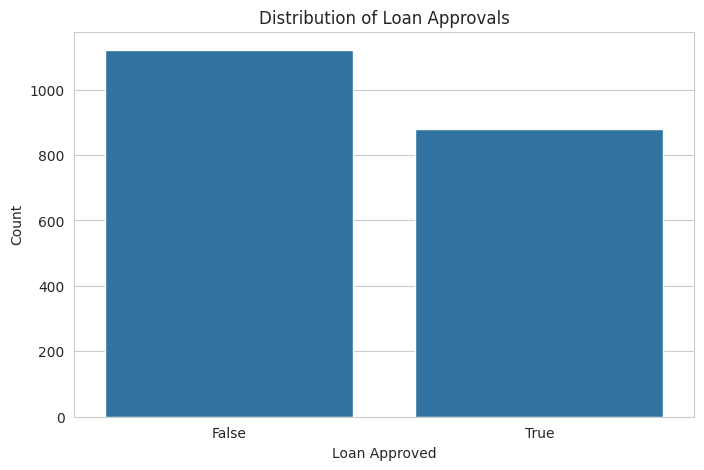

In [8]:
#Visualizing the Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='loan_approved')
plt.title('Distribution of Loan Approvals')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

##FEATURE ANALYSIS

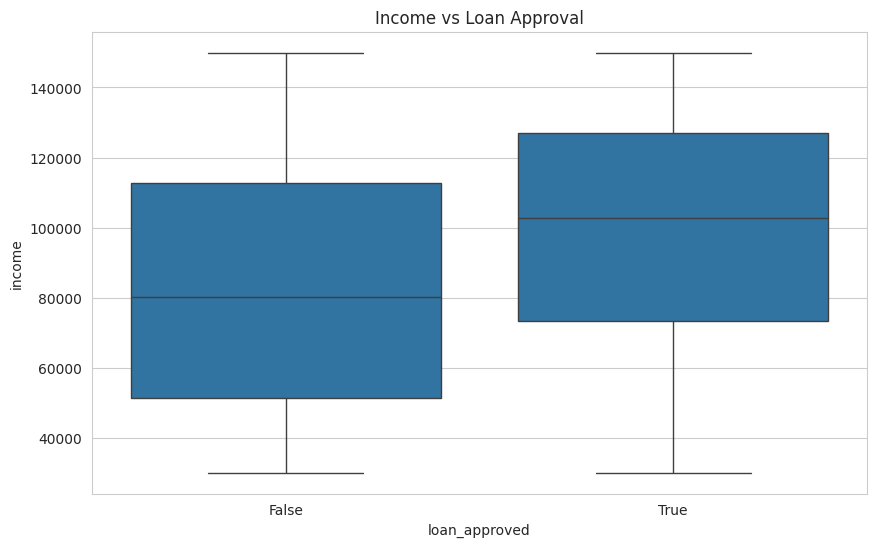

In [9]:
# Income distribution by loan approval

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='loan_approved', y='income')
plt.title('Income vs Loan Approval')
plt.show()


Income seems to be an important factor in loan approval — applicants with higher incomes are more likely to have their loans approved.

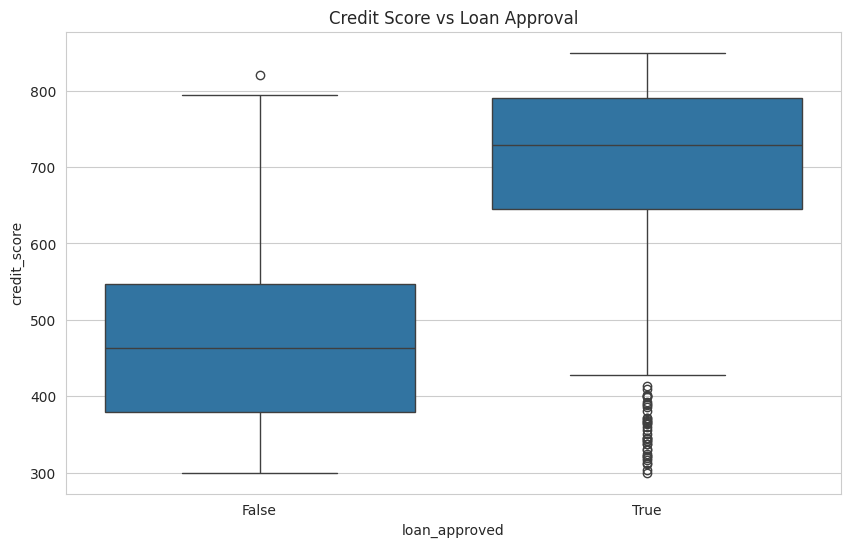

In [10]:
#Credit score distribution by loan approval

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='loan_approved', y='credit_score')
plt.title('Credit Score vs Loan Approval')
plt.show()

The low-credit-score outliers among approved loans suggest that loan approval decisions consider multiple factors beyond credit score alone.

In [11]:
df.columns.to_list()

['name',
 'city',
 'income',
 'credit_score',
 'loan_amount',
 'years_employed',
 'points',
 'loan_approved']

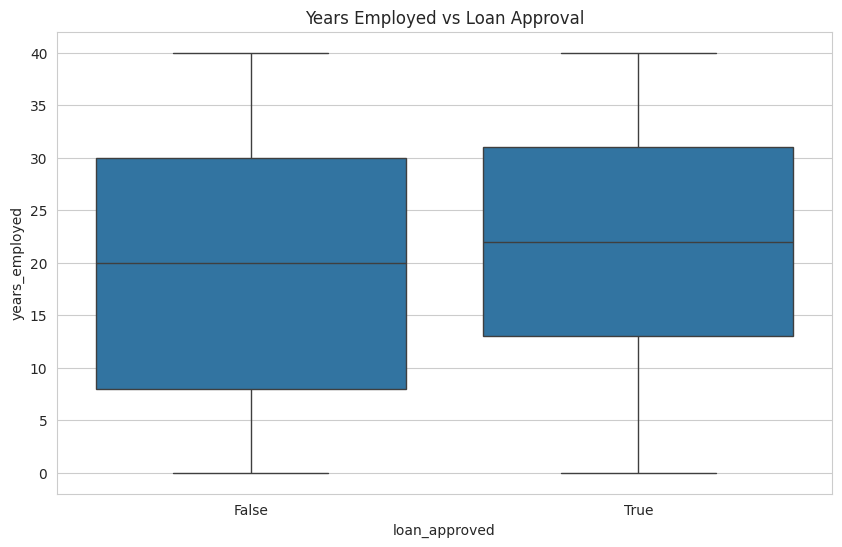

In [12]:
#Years employed by loan approval

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='loan_approved', y='years_employed')
plt.title('Years Employed vs Loan Approval')
plt.show()

In [13]:
# Correlation analysis for numerical features
print("\nCorrelation with Loan Approval:")

# First, convert boolean to numeric for correlation
df['loan_approved_numeric'] = df['loan_approved'].astype(int)
correlations = df[['income', 'credit_score', 'loan_amount', 'years_employed', 'points']].corrwith(df['loan_approved_numeric'])
print(correlations.sort_values(ascending=False))


Correlation with Loan Approval:
points            0.821415
credit_score      0.715788
income            0.238066
years_employed    0.104408
loan_amount      -0.157859
dtype: float64


Understanding correlation:
- Positive correlation (0 to 1): Higher feature value = more likely approved
- Negative correlation (-1 to 0): Higher feature value = less likely approved
- Close to 0: Feature doesn't strongly relate to approval

#DATA PREPROCESSING

Now we prepare our data for machine learning models.
Think of this like preparing ingredients before cooking.

Steps we'll take:
1. Handle missing values (if any)
2. Remove unnecessary columns (like 'name')
3. Encode categorical variables (convert text to numbers)
4. Split data into training and testing sets
5. Scale numerical features

Why each step matters:
- Models can't handle missing data
- Models can't directly use text (need numbers)
- We need separate data to test if our model actually works
- Scaling prevents features with big numbers from dominating

In [14]:
#DROP UNNECESSARY COLUMNS

#Drop 'name' column (doesn't help prediction)
print("Before dropping 'name' column:")
print(df.columns)
df = df.drop('name', axis=1)

print("-" * 60)
print("\nAfter dropping 'name' column:")
print(df.columns)
print("Dropped 'name' column")

Before dropping 'name' column:
Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved', 'loan_approved_numeric'],
      dtype='object')
------------------------------------------------------------

After dropping 'name' column:
Index(['city', 'income', 'credit_score', 'loan_amount', 'years_employed',
       'points', 'loan_approved', 'loan_approved_numeric'],
      dtype='object')
Dropped 'name' column


Why drop 'name'?
- Each person's name is unique
- It doesn't tell us if they'll repay the loan
- Including it would confuse the model

#ENCODE CATEGORICAL VARIABLES


ENCODING EXPLAINED


Machine learning models only understand NUMBERS, not text.
So we need to convert text categories into numbers.

Example: If 'city' has values ['Lagos', 'Abuja', 'Port Harcourt']
We might encode as: Lagos=0, Abuja=1, Port Harcourt=2

Two main encoding methods:
1. Label Encoding: For ordinal data (has order/ranking)
2. One-Hot Encoding: For nominal data (no order)

For 'city', we'll use One-Hot Encoding because there's no inherent order

In [15]:
#One-hot encode 'city'
'''df = pd.get_dummies(df, columns=['city'], drop_first=True)
print("City column encoded!")'''
df.head()

,city,income,credit_score,loan_amount,years_employed,points,loan_approved,loan_approved_numeric
0,East Jill,113810,389,39698,27,50.0,False,0
1,New Jamesside,44592,729,15446,28,55.0,False,0
2,Lake Roberto,33278,584,11189,13,45.0,False,0
3,West Melanieview,127196,344,48823,29,50.0,False,0
4,Mariastad,66048,496,47174,4,25.0,False,0


In [16]:
pd.set_option('display.max_rows', None)
df['city'].value_counts()

,count
city,
North Joseph,4
Williamsstad,3
Port Christopher,3
Port Michael,3
Leeland,3
West Melissa,3
East Mary,3
North David,3
Christinachester,3


City seems to be a high-cardinality categorical feature:
---
1000+ unique cities

Most appear only once

Only a few repeat


If we one-hot encode this:
---
We’ll create 1000+ columns

Most will be almost always 0

This adds noise and hurts most models

In [17]:
#drop city
print(df.columns)
df = df.drop('city', axis=1)

Index(['city', 'income', 'credit_score', 'loan_amount', 'years_employed',
       'points', 'loan_approved', 'loan_approved_numeric'],
      dtype='object')


In [18]:
df.columns

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points',
       'loan_approved', 'loan_approved_numeric'],
      dtype='object')

#SEPARATE FEATURES AND TARGET



FEATURES vs TARGET


- Features (X): The information we use to make predictions
  Example: income, credit_score, etc.
  
- Target (y): What we're trying to predict
  Example: loan_approved





In [19]:
#Separate X and y
X = df.drop(['loan_approved', 'loan_approved_numeric'], axis=1)
y = df['loan_approved'].astype(int)  # Convert True/False to 1/0

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (2000, 5)
Target shape: (2000,)


In [20]:
X

,income,credit_score,loan_amount,years_employed,points
0,113810,389,39698,27,50.0
1,44592,729,15446,28,55.0
2,33278,584,11189,13,45.0
3,127196,344,48823,29,50.0
4,66048,496,47174,4,25.0
5,62098,689,19217,29,65.0
6,59256,373,40920,40,35.0
7,48289,524,45866,20,25.0
8,126530,367,14826,36,55.0
9,43434,446,18359,8,20.0


In [21]:
y

,loan_approved
0,0
1,0
2,0
3,0
4,0
5,1
6,0
7,0
8,0
9,0


In [22]:
#Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep same proportion of approved/rejected in both sets
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1600, 5)
Test set: (400, 5)


What is stratify=y?
- Ensures both train and test have same % of approved/rejected loans
- Example: If 70% approved in full data, both train and test will have ~70%
- This prevents bias from random splitting

FEATURE SCALING
==========================

Problem: Different features have different ranges
- Income: 30,000 to 200,000
- Credit Score: 300 to 850
- Years Employed: 0 to 40

Why this matters:
The model might think income is more important just because
the numbers are bigger! But that's not fair.

Solution: StandardScaler
- Transforms all features to have mean=0 and standard deviation=1


In [23]:
scaler = StandardScaler()

# Fit on training data (learn the mean and std)
# Transform both training and test data using those statistics
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"Example - Before scaling: {X_train.iloc[0]['income']}")
print(f"Example - After scaling: {X_train_scaled[0][0]:.2f}")

Features scaled successfully!
Example - Before scaling: 84935.0
Example - After scaling: -0.17


IMPORTANT: Why fit_transform on train, but only transform on test?

- fit_transform: Calculate mean/std from data AND apply scaling
- transform: Use already calculated mean/std to apply scaling

We only learn statistics from TRAINING data, then apply to BOTH sets.
Why? In real life, we won't have test data statistics - only training.

MODEL BUILDING - CLASSIFICATION ALGORITHMS
===========================================

We'll build and compare THREE different classification models:

1. LOGISTIC REGRESSION
   - Simple, fast, interpretable
   - Works well as a baseline
   - Despite the name, it's for CLASSIFICATION, not regression!
   
2. DECISION TREE
   - Makes decisions like a flowchart
   - Easy to understand and visualize
   - Can capture non-linear patterns
   
3. RANDOM FOREST
   - Combines many decision trees
   - Usually more accurate than single tree
   - More robust to overfitting

Let's build each model and see which performs best!

LOGISTIC REGRESSION EXPLAINED
==============================

How it works:
- Looks at all features and calculates a probability (0 to 1)
- If probability > 0.5 → Predict Approved (1)
- If probability < 0.5 → Predict Rejected (0)

Think of it like:
- The model learns: "High income + high credit score = high probability"

In [24]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained!")

# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)
print("Predictions made!")


Logistic Regression trained!
Predictions made!


DECISION TREE EXPLAINED
========================

How it works:
- Makes decisions step by step, like a flowchart
- Example:
  1. Is credit_score > 700?
     - Yes → Is income > 50,000?
       - Yes → APPROVE
       - No → REJECT
     - No → REJECT

Advantages:
- Easy to understand
- Can handle non-linear relationships
- No need for feature scaling

Disadvantages:
- Can overfit (memorize training data)
- Small changes in data can change entire tree

In [25]:
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_clf.fit(X_train_scaled, y_train)
print("Decision Tree trained!")

# Make predictions
y_pred_dt = dt_clf.predict(X_test_scaled)
print("Predictions made!")



Decision Tree trained!
Predictions made!


What is max_depth=5?
- Limits how many questions the tree can ask
- Prevents overfitting (tree getting too complex)
- Like saying: "You can only ask 5 questions max"

RANDOM FOREST EXPLAINED
========================

How it works:
- Builds MANY decision trees (hence "forest")
- Each tree votes on the prediction
- Final prediction = majority vote

Example: 100 trees
- 70 trees say "Approve"
- 30 trees say "Reject"
- Final prediction: Approve!

Why it's better than single tree:
- Less likely to overfit
- More stable and accurate
- Like asking 100 experts instead of just 1!


In [26]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_scaled, y_train)
print("Random Forest trained!")

"""
Parameters explained:
- n_estimators=100: Build 100 trees
- max_depth=10: Each tree can ask up to 10 questions
- random_state=42: For reproducibility
"""

# Make predictions
y_pred_rf = rf_clf.predict(X_test_scaled)
print("Predictions made!")

Random Forest trained!
Predictions made!


MODEL EVALUATION - HOW GOOD IS OUR MODEL?
==========================================

We need to measure how well each model performs.
But "good" depends on the BUSINESS PROBLEM!

Key Metrics for Classification:

1. ACCURACY
   - What % of predictions were correct?
   - Formula: (Correct predictions) / (Total predictions)
   - Example: 85% accuracy = 85 out of 100 predictions were right
   
2. PRECISION
   - Of all loans we approved, what % were actually good?
   - Formula: True Positives / (True Positives + False Positives)
   - Business meaning: How many bad loans did we wrongly approve?
   
3. RECALL (Sensitivity)
   - Of all good loans, what % did we approve?
   - Formula: True Positives / (True Positives + False Negatives)
   - Business meaning: How many good customers did we wrongly reject?
   
4. F1-SCORE
   - Harmonic mean of Precision and Recall
   - Useful when you want balance between both
   
5. CONFUSION MATRIX
   - Shows all four types of predictions:
     * True Positives (TP): Correctly approved good loans
     * True Negatives (TN): Correctly rejected bad loans
     * False Positives (FP): Wrongly approved bad loans (Type I error)
     * False Negatives (FN): Wrongly rejected good loans (Type II error)



BUSINESS CONTEXT MATTERS!
==========================

For Loan Approval:

Scenario 1: Bank is conservative (doesn't want to lose money)
- Prioritize PRECISION
- Better to reject some good customers than approve bad loans
- Missing good customers (False Negatives) is acceptable
- Approving bad loans (False Positives) is VERY costly

Scenario 2: Bank wants to grow customer base
- Prioritize RECALL
- Don't want to reject good customers
- Some bad loans (False Positives) are acceptable
- Missing good customers (False Negatives) is costly

Today, let's assume: BALANCED APPROACH
- We care about both Precision and Recall
- F1-Score is a good overall metric
- But we'll look at all metrics to understand trade-offs

In [27]:
def evaluate_model(model_name, y_test, y_pred):


    # Calculate all metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print metrics
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

    '''print(f"\n{'-'*70}")
    print("WHAT THESE NUMBERS MEAN:")
    print(f"{'-'*70}")
    print(f"✓ Model got {accuracy*100:.2f}% of predictions correct")
    print(f"✓ Of approved loans, {precision*100:.2f}% were actually good")
    print(f"✓ Of good loans, we approved {recall*100:.2f}% of them")
    print(f"✓ F1-Score balances precision and recall: {f1*100:.2f}%")'''

    # Confusion Matrix
    print(f"\n{'-'*70}")
    print("CONFUSION MATRIX:")
    print(f"{'-'*70}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    '''print(f"\nBreakdown:")
    print(f"  True Negatives (Correctly Rejected):  {cm[0][0]}")
    print(f"  False Positives (Wrongly Approved):   {cm[0][1]} ⚠️")
    print(f"  False Negatives (Wrongly Rejected):   {cm[1][0]} ⚠️")
    print(f"  True Positives (Correctly Approved):  {cm[1][1]}")'''

    # Classification Report
    print(f"\n{'-'*70}")
    print("DETAILED CLASSIFICATION REPORT:")
    print(f"{'-'*70}")
    print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

    # Return metrics as dictionary
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

In [28]:
#Evaluate each model using our function

# Evaluate Logistic Regression
log_reg_results = evaluate_model("Logistic Regression", y_test, y_pred_log)

# Evaluate Decision Tree
dt_results = evaluate_model("Decision Tree", y_test, y_pred_dt)

# Evaluate Random Forest
rf_results = evaluate_model("Random Forest", y_test, y_pred_rf)


Accuracy:  1.0000 (100.00%)
Precision: 1.0000 (100.00%)
Recall:    1.0000 (100.00%)
F1-Score:  1.0000 (100.00%)

----------------------------------------------------------------------
CONFUSION MATRIX:
----------------------------------------------------------------------
[[224   0]
 [  0 176]]

----------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       224
    Approved       1.00      1.00      1.00       176

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Accuracy:  1.0000 (100.00%)
Precision: 1.0000 (100.00%)
Recall:    1.0000 (100.00%)
F1-Score:  1.0000 (100.00%)

----------------------------------------------------------------------
CONFUSION MATRIX:


In [29]:
# Check 1: What are the shapes?
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check 2: Look at a few predictions vs actual
print("\nFirst 20 predictions:")
print(y_pred_rf[:20])
print("\nFirst 20 actual values:")
print(y_test.values[:20])

# Check 3: Are they ALL correct?
print("\nNumber of correct predictions:", (y_pred_rf == y_test).sum())
print("Total predictions:", len(y_test))
print("Accuracy:", (y_pred_rf == y_test).sum() / len(y_test))

# Check 4: Class distribution
print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts())
print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts())

# Check 5: Look at the ORIGINAL X (before scaling) - what columns did it have?
print("\nOriginal X columns (before scaling):")
print(X.columns.tolist())

# Check 6: Does X still have 'loan_approved' by accident?
if 'loan_approved' in X.columns:
    print("\n⚠️ WARNING: 'loan_approved' is still in your features! DATA LEAKAGE!")
else:
    print("\n✓ 'loan_approved' not in features (good)")

X_train_scaled shape: (1600, 5)
X_test_scaled shape: (400, 5)
y_train shape: (1600,)
y_test shape: (400,)

First 20 predictions:
[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]

First 20 actual values:
[1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 0]

Number of correct predictions: 400
Total predictions: 400
Accuracy: 1.0

Class distribution in y_train:
loan_approved
0    897
1    703
Name: count, dtype: int64

Class distribution in y_test:
loan_approved
0    224
1    176
Name: count, dtype: int64

Original X columns (before scaling):
['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

✓ 'loan_approved' not in features (good)


In [30]:
# Let's start completely fresh and trace through everything

print("="*70)
print("STEP 1: CHECK ORIGINAL DATAFRAME")
print("="*70)
print("\nAll columns in df:")
print(df.columns.tolist())

print("\nDataFrame shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\n" + "="*70)
print("STEP 2: CHECK WHAT'S IN X AND y")
print("="*70)
print("\nColumns in X:")
print(X.columns.tolist())
print("\nX shape:", X.shape)

print("\nFirst row of X:")
print(X.iloc[0])

print("\ny unique values:", np.unique(y))
print("y value counts:")
print(pd.Series(y).value_counts())

print("\n" + "="*70)
print("STEP 3: CHECK CORRELATION")
print("="*70)
# Check if any feature is perfectly correlated with target
temp_df = X.copy()
temp_df['target'] = y

correlations = temp_df.corr()['target'].sort_values(ascending=False)
print("\nCorrelation with target:")
print(correlations)

print("\n⚠️ If any feature has correlation = 1.0 or -1.0, that's data leakage!")

print("\n" + "="*70)
print("STEP 4: MANUAL PREDICTION TEST")
print("="*70)
# Let's manually check one prediction
print("\nFirst test sample (original values before scaling):")
print(X_test.iloc[0])
print("\nActual label:", y_test.iloc[0])
print("\nModel prediction:", y_pred_rf[0])
print("\nPrediction probability:", rf_clf.predict_proba(X_test_scaled)[0])

STEP 1: CHECK ORIGINAL DATAFRAME

All columns in df:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points', 'loan_approved', 'loan_approved_numeric']

DataFrame shape: (2000, 7)

First few rows:
   income  credit_score  loan_amount  years_employed  points  loan_approved  \
0  113810           389        39698              27    50.0          False   
1   44592           729        15446              28    55.0          False   
2   33278           584        11189              13    45.0          False   
3  127196           344        48823              29    50.0          False   
4   66048           496        47174               4    25.0          False   

   loan_approved_numeric  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  

STEP 2: CHECK WHAT'S IN X AND y

Columns in X:
['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

X shape: (2000, 5)

First row of X